# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


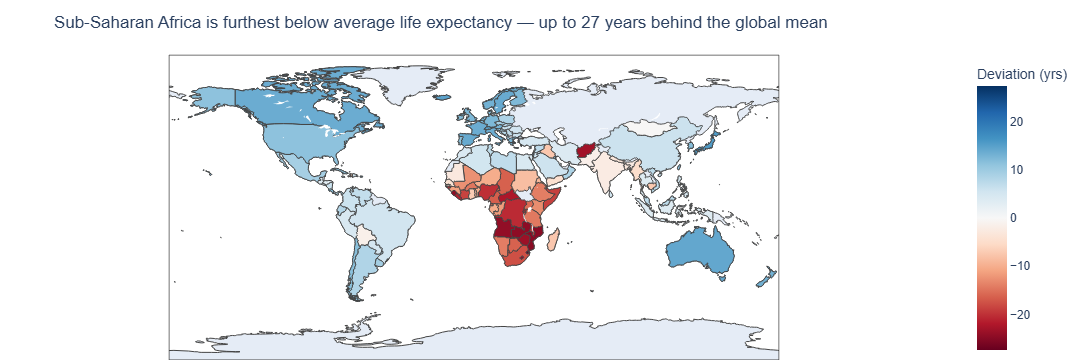

In [2]:
# Task 1

# Load Gapminder 2007
gm_2007 = px.data.gapminder().query("year == 2007").copy()

# Compute deviation from global mean
global_mean = gm_2007['lifeExp'].mean()  # ≈ 67.0 years
gm_2007['lifeExp_dev'] = gm_2007['lifeExp'] - global_mean

# Build choropleth
# px.choropleth chosen: data is world-level with ISO-3 codes — built-in geometry
# is the right tool; no custom GeoJSON needed.
# Diverging scale (RdBu) centred at 0 because the variable is above/below average.
fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    locationmode='ISO-3',
    color='lifeExp_dev',
    hover_name='country',
    hover_data={
        'lifeExp': ':.1f',
        'lifeExp_dev': ':.1f',
        'iso_alpha': False
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    labels={
        'lifeExp_dev': 'Deviation from global avg (yrs)',
        'lifeExp': 'Life Expectancy (yrs)'
    },
    title='Sub-Saharan Africa is furthest below average life expectancy — up to 27 years behind the global mean',
)

fig.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(title='Deviation (yrs)')
)

fig.show()

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


In [3]:
# Task 2 — Germany Bundesländer unemployment rate choropleth

import urllib.request

# Load GeoJSON from GitHub
url = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json'
with urllib.request.urlopen(url) as response:
    germany_geojson = json.load(response)

# Inspect properties to confirm featureidkey
print(germany_geojson['features'][0]['properties'])
# → {'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}
# featureidkey = 'properties.name'

{'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}


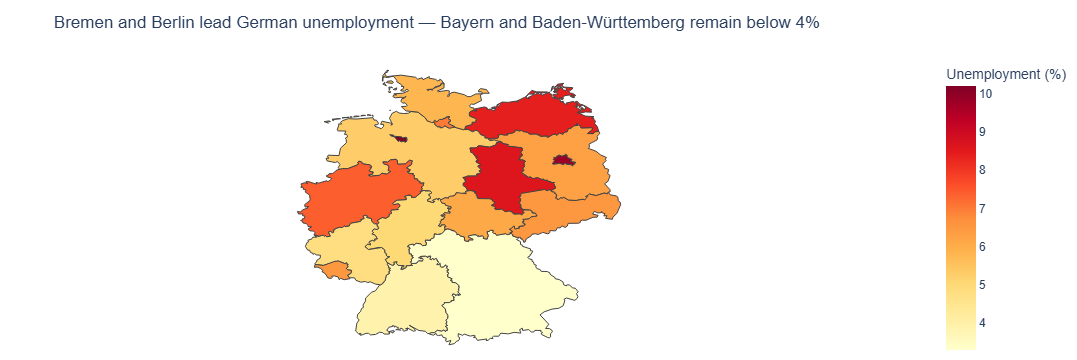

In [4]:
# Unemployment rates by German state (Bundesagentur für Arbeit, 2023 annual avg)
unemployment = pd.DataFrame({
    'state': [
        'Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen',
        'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen',
        'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland',
        'Sachsen-Anhalt', 'Sachsen', 'Schleswig-Holstein', 'Thüringen'
    ],
    'unemployment_rate': [
        3.9, 3.3, 9.8, 6.3, 10.2,
        7.0, 5.0, 8.4, 5.3,
        7.4, 4.8, 6.5,
        8.6, 6.5, 5.8, 6.1
    ]
})

fig2 = px.choropleth(
    unemployment,
    geojson=germany_geojson,
    locations='state',
    featureidkey='properties.name',
    color='unemployment_rate',
    color_continuous_scale='YlOrRd',
    labels={'unemployment_rate': 'Unemployment Rate (%)'},
    hover_name='state',
    hover_data={'state': False, 'unemployment_rate': ':.1f'},
    title='Bremen and Berlin lead German unemployment — Bayern and Baden-Württemberg remain below 4%',
    fitbounds='locations',
    basemap_visible=False,
)

fig2.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(title='Unemployment (%)')
)

fig2.show()
